Comparison: Credit Card vs PaySim

This notebook creates a **separate advanced comparison section** for the diploma:
- clean comparison tables
- ranking tables
- best model summary
- advanced charts
- exported CSV and Excel files

## 1. Imports

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load result files

This notebook expects these files:
- `creditcard_final_results.csv`
- `paysim_final_results.csv`

Run the dataset notebooks first so these files are created.

In [19]:
def find_existing_file(candidates):
    for path in candidates:
        if os.path.exists(path):
            return path
    return None

credit_candidates = [
    "creditcard_final_results.csv",
    "/content/creditcard_final_results.csv",
    "/mnt/data/creditcard_final_results.csv"
]

paysim_candidates = [
    "paysim_final_results.csv",
    "/content/paysim_final_results.csv",
    "/mnt/data/paysim_final_results.csv"
]

credit_path = find_existing_file(credit_candidates)
paysim_path = find_existing_file(paysim_candidates)

print("Credit Card results file:", credit_path)
print("PaySim results file:", paysim_path)

if credit_path is None or paysim_path is None:
    raise FileNotFoundError(
        "Required CSV results files were not found. "
        "Please run the Credit Card and PaySim notebooks first."
    )

credit_df = pd.read_csv(credit_path)
paysim_df = pd.read_csv(paysim_path)

print("Credit Card shape:", credit_df.shape)
print("PaySim shape:", paysim_df.shape)

Credit Card results file: creditcard_final_results.csv
PaySim results file: paysim_final_results.csv
Credit Card shape: (7, 13)
PaySim shape: (7, 6)


## 3. Clean and standardize tables

In [20]:
metric_cols = ["Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]

for df in [credit_df, paysim_df]:
    for col in metric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

credit_df["Dataset"] = "Credit Card"
paysim_df["Dataset"] = "PaySim"

combined_df = pd.concat([credit_df, paysim_df], ignore_index=True)
combined_df = combined_df.sort_values(["Dataset", "F1-score"], ascending=[True, False]).reset_index(drop=True)

combined_df.head()

,Dataset,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC,TN,FP,FN,TP,Train Time (s),Test Time (s)
0,Credit Card,Elliptic Envelope,0.800448,0.807692,0.804054,0.955042,0.788085,48548.0,89.0,85.0,357.0,129.979813,0.079918
1,Credit Card,Tuned Isolation Forest,0.740964,0.556561,0.635659,0.954091,0.670048,48551.0,86.0,196.0,246.0,22.631205,1.823850
2,Credit Card,Autoencoder,0.742537,0.450226,0.560563,0.957989,0.617632,48568.0,69.0,243.0,199.0,21.439331,2.220806
3,Credit Card,One-Class SVM,0.402039,0.803167,0.535849,0.946343,0.652992,48109.0,528.0,87.0,355.0,145.615246,9.206314
4,Credit Card,Isolation Forest,0.709544,0.386878,0.500732,0.950824,0.510580,48567.0,70.0,271.0,171.0,1.561834,0.348401


## 4. Separate comparison tables for each dataset

In [21]:
credit_comparison = credit_df[["Model", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]].copy()
credit_comparison = credit_comparison.sort_values("F1-score", ascending=False).reset_index(drop=True)
credit_comparison.insert(0, "Rank", range(1, len(credit_comparison) + 1))

paysim_comparison = paysim_df[["Model", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]].copy()
paysim_comparison = paysim_comparison.sort_values("F1-score", ascending=False).reset_index(drop=True)
paysim_comparison.insert(0, "Rank", range(1, len(paysim_comparison) + 1))

print("Credit Card comparison table")
display(credit_comparison.round(4))

print("PaySim comparison table")
display(paysim_comparison.round(4))

Credit Card comparison table


,Rank,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,1,Elliptic Envelope,0.8004,0.8077,0.8041,0.9550,0.7881
1,2,Tuned Isolation Forest,0.7410,0.5566,0.6357,0.9541,0.6700
2,3,Autoencoder,0.7425,0.4502,0.5606,0.9580,0.6176
3,4,One-Class SVM,0.4020,0.8032,0.5358,0.9463,0.6530
4,5,Isolation Forest,0.7095,0.3869,0.5007,0.9508,0.5106
5,6,k-Means,0.6522,0.3394,0.4464,0.9597,0.5065
6,7,Local Outlier Factor,0.0526,0.0090,0.0154,0.8515,0.0579


PaySim comparison table


,Rank,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,1,Autoencoder,0.4912,0.1373,0.2146,0.8302,0.1434
1,2,Tuned Isolation Forest,0.2800,0.0686,0.1102,0.7795,0.0671
2,3,One-Class SVM,0.0659,0.2647,0.1055,0.7783,0.0762
3,4,Local Outlier Factor,0.1852,0.0490,0.0775,0.6893,0.0553
4,5,k-Means,0.1579,0.0294,0.0496,0.7598,0.0373
5,6,Elliptic Envelope,0.0417,0.0098,0.0159,0.6551,0.0121
6,7,Isolation Forest,0.0000,0.0000,0.0000,0.7361,0.0062


## 5. Combined advanced comparison table

In [22]:
advanced_comparison = combined_df[["Dataset", "Model", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]].copy()
advanced_comparison = advanced_comparison.sort_values(["Dataset", "F1-score"], ascending=[True, False]).reset_index(drop=True)
advanced_comparison_round = advanced_comparison.round(4)

advanced_comparison_round

,Dataset,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Credit Card,Elliptic Envelope,0.8004,0.8077,0.8041,0.9550,0.7881
1,Credit Card,Tuned Isolation Forest,0.7410,0.5566,0.6357,0.9541,0.6700
2,Credit Card,Autoencoder,0.7425,0.4502,0.5606,0.9580,0.6176
3,Credit Card,One-Class SVM,0.4020,0.8032,0.5358,0.9463,0.6530
4,Credit Card,Isolation Forest,0.7095,0.3869,0.5007,0.9508,0.5106
5,Credit Card,k-Means,0.6522,0.3394,0.4464,0.9597,0.5065
6,Credit Card,Local Outlier Factor,0.0526,0.0090,0.0154,0.8515,0.0579
7,PaySim,Autoencoder,0.4912,0.1373,0.2146,0.8302,0.1434
8,PaySim,Tuned Isolation Forest,0.2800,0.0686,0.1102,0.7795,0.0671
9,PaySim,One-Class SVM,0.0659,0.2647,0.1055,0.7783,0.0762


## 6. Best model summary

In [23]:
best_by_dataset = advanced_comparison.loc[
    advanced_comparison.groupby("Dataset")["F1-score"].idxmax()
].sort_values("Dataset").reset_index(drop=True)

overall_best = advanced_comparison.sort_values("F1-score", ascending=False).head(1).reset_index(drop=True)

print("Best model in each dataset:")
display(best_by_dataset.round(4))

print("Overall best model across both datasets:")
display(overall_best.round(4))

Best model in each dataset:


,Dataset,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Credit Card,Elliptic Envelope,0.8004,0.8077,0.8041,0.9550,0.7881
1,PaySim,Autoencoder,0.4912,0.1373,0.2146,0.8302,0.1434


Overall best model across both datasets:


,Dataset,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Credit Card,Elliptic Envelope,0.8004,0.8077,0.8041,0.955,0.7881


## 7. Ranking comparison between datasets

In [24]:
rank_table = advanced_comparison.copy()
rank_table["Rank"] = rank_table.groupby("Dataset")["F1-score"].rank(method="dense", ascending=False).astype(int)
rank_table = rank_table[["Dataset", "Rank", "Model", "F1-score", "ROC-AUC", "PR-AUC"]]
rank_table = rank_table.sort_values(["Dataset", "Rank"]).reset_index(drop=True)

rank_table.round(4)

,Dataset,Rank,Model,F1-score,ROC-AUC,PR-AUC
0,Credit Card,1,Elliptic Envelope,0.8041,0.9550,0.7881
1,Credit Card,2,Tuned Isolation Forest,0.6357,0.9541,0.6700
2,Credit Card,3,Autoencoder,0.5606,0.9580,0.6176
3,Credit Card,4,One-Class SVM,0.5358,0.9463,0.6530
4,Credit Card,5,Isolation Forest,0.5007,0.9508,0.5106
5,Credit Card,6,k-Means,0.4464,0.9597,0.5065
6,Credit Card,7,Local Outlier Factor,0.0154,0.8515,0.0579
7,PaySim,1,Autoencoder,0.2146,0.8302,0.1434
8,PaySim,2,Tuned Isolation Forest,0.1102,0.7795,0.0671
9,PaySim,3,One-Class SVM,0.1055,0.7783,0.0762


## 8. Export tables

In [25]:
credit_comparison.round(6).to_csv("creditcard_model_comparison_advanced.csv", index=False)
paysim_comparison.round(6).to_csv("paysim_model_comparison_advanced.csv", index=False)
advanced_comparison_round.to_csv("combined_model_comparison_advanced.csv", index=False)
rank_table.round(6).to_csv("model_ranking_comparison.csv", index=False)
best_by_dataset.round(6).to_csv("best_models_by_dataset.csv", index=False)

with pd.ExcelWriter("advanced_model_comparison.xlsx", engine="openpyxl") as writer:
    credit_comparison.round(6).to_excel(writer, sheet_name="CreditCard", index=False)
    paysim_comparison.round(6).to_excel(writer, sheet_name="PaySim", index=False)
    advanced_comparison_round.to_excel(writer, sheet_name="Combined", index=False)
    rank_table.round(6).to_excel(writer, sheet_name="Ranking", index=False)
    best_by_dataset.round(6).to_excel(writer, sheet_name="BestModels", index=False)

print("Export complete.")

Export complete.


## 9. Chart 1 — F1-score comparison

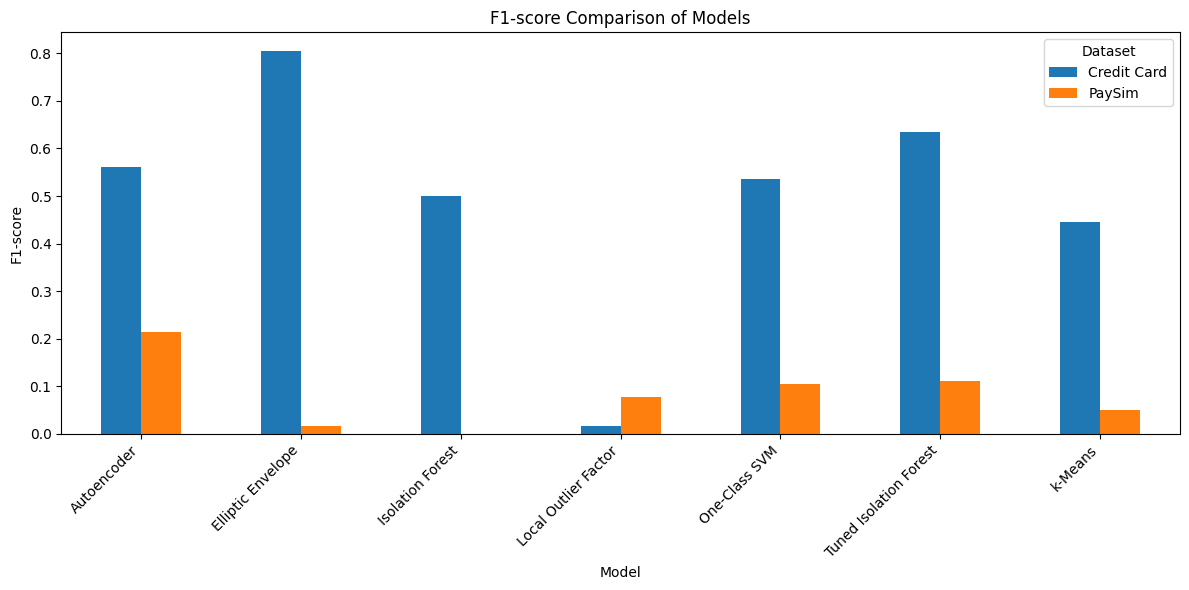

In [26]:
pivot_f1 = advanced_comparison.pivot(index="Model", columns="Dataset", values="F1-score")
ax = pivot_f1.plot(kind="bar", figsize=(12, 6))
ax.set_title("F1-score Comparison of Models")
ax.set_xlabel("Model")
ax.set_ylabel("F1-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 10. Chart 2 — ROC-AUC comparison

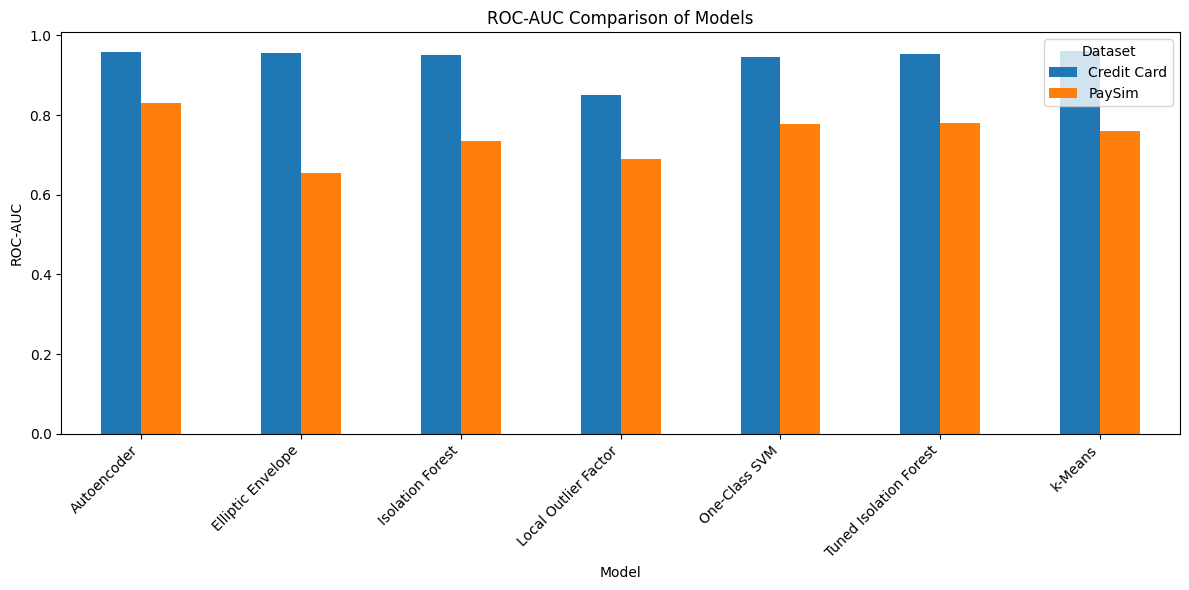

In [27]:
pivot_roc = advanced_comparison.pivot(index="Model", columns="Dataset", values="ROC-AUC")
ax = pivot_roc.plot(kind="bar", figsize=(12, 6))
ax.set_title("ROC-AUC Comparison of Models")
ax.set_xlabel("Model")
ax.set_ylabel("ROC-AUC")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 11. Chart 3 — PR-AUC comparison

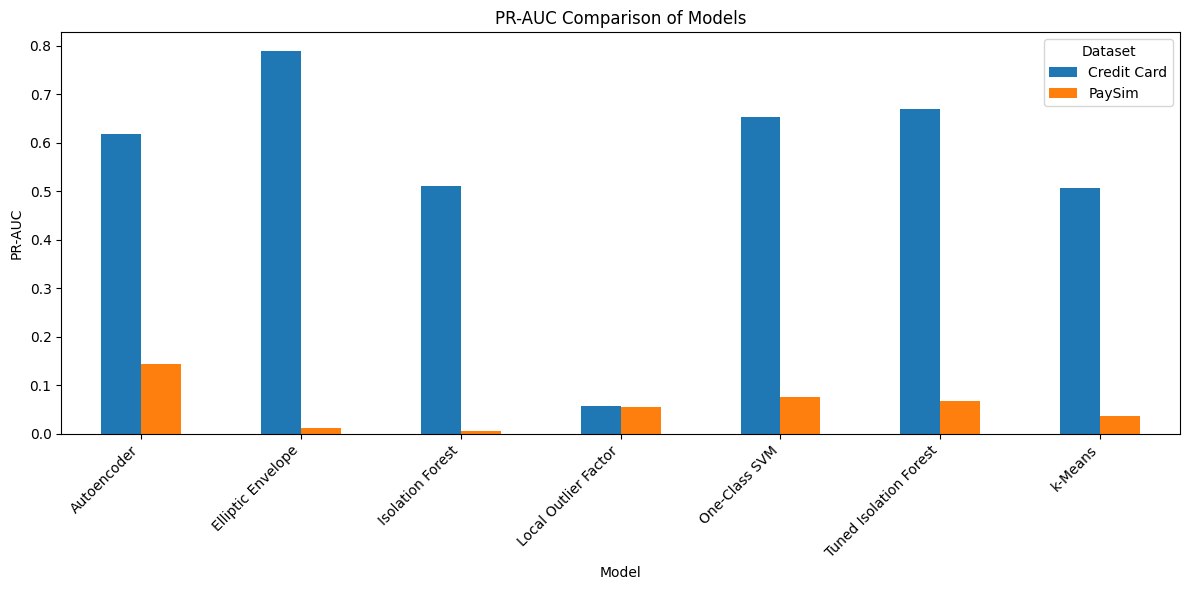

In [28]:
pivot_pr = advanced_comparison.pivot(index="Model", columns="Dataset", values="PR-AUC")
ax = pivot_pr.plot(kind="bar", figsize=(12, 6))
ax.set_title("PR-AUC Comparison of Models")
ax.set_xlabel("Model")
ax.set_ylabel("PR-AUC")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 12. Chart 4 — Precision and Recall by dataset

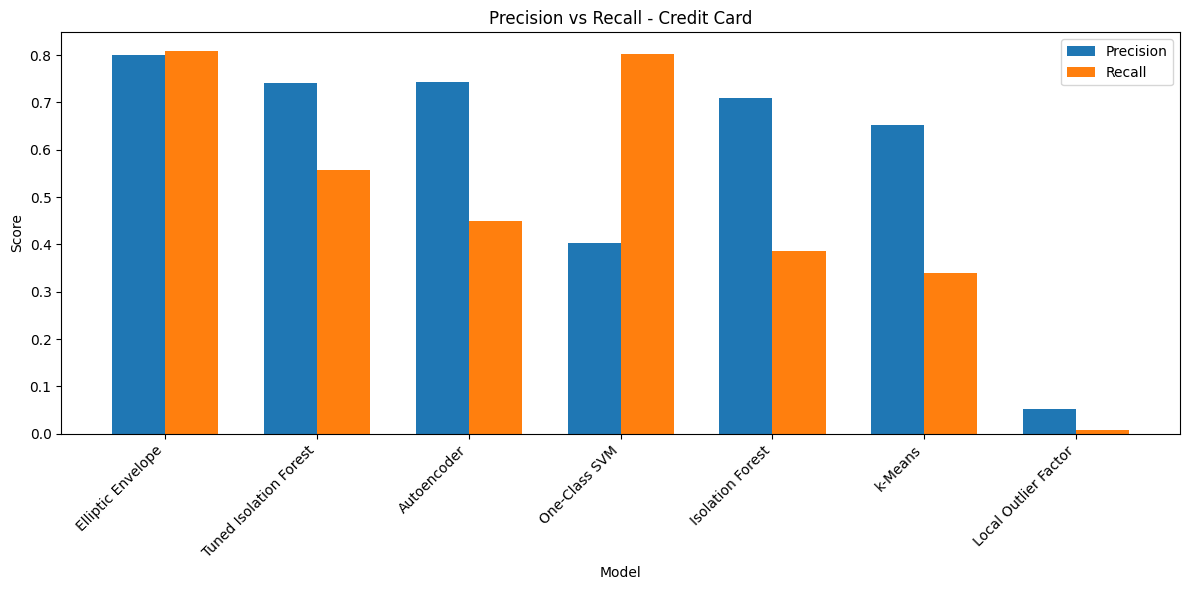

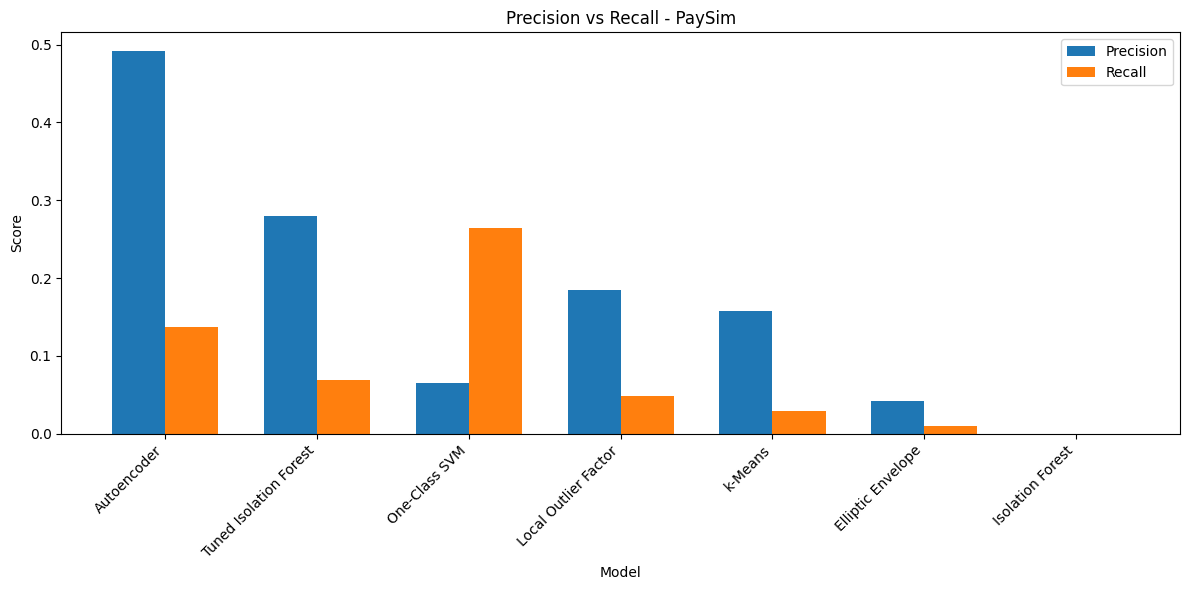

In [29]:
for dataset_name in advanced_comparison["Dataset"].unique():
    subset = advanced_comparison[advanced_comparison["Dataset"] == dataset_name].copy()
    subset = subset.sort_values("F1-score", ascending=False)

    x = np.arange(len(subset))
    width = 0.35

    plt.figure(figsize=(12, 6))
    plt.bar(x - width/2, subset["Precision"], width=width, label="Precision")
    plt.bar(x + width/2, subset["Recall"], width=width, label="Recall")
    plt.xticks(x, subset["Model"], rotation=45, ha="right")
    plt.title(f"Precision vs Recall - {dataset_name}")
    plt.xlabel("Model")
    plt.ylabel("Score")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 13. Chart 5 — Precision vs Recall scatter plot

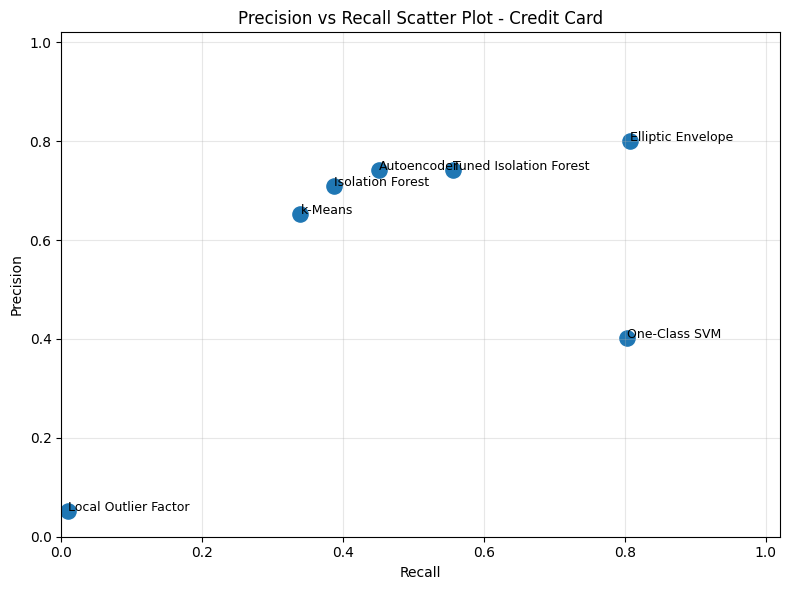

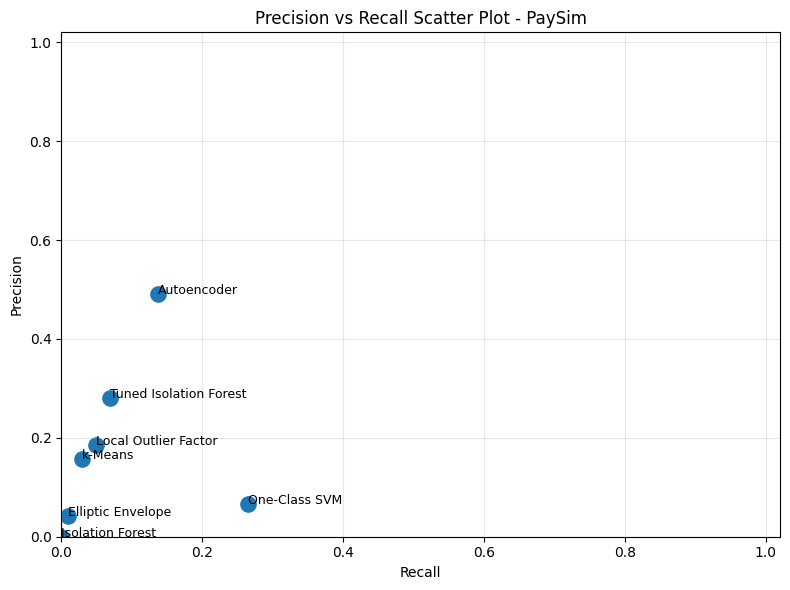

In [30]:
for dataset_name in advanced_comparison["Dataset"].unique():
    subset = advanced_comparison[advanced_comparison["Dataset"] == dataset_name].copy()

    plt.figure(figsize=(8, 6))
    plt.scatter(subset["Recall"], subset["Precision"], s=120)

    for _, row in subset.iterrows():
        plt.annotate(row["Model"], (row["Recall"], row["Precision"]), fontsize=9)

    plt.title(f"Precision vs Recall Scatter Plot - {dataset_name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.xlim(0, 1.02)
    plt.ylim(0, 1.02)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 14. Chart 6 — Heatmap-style matrix for F1-score

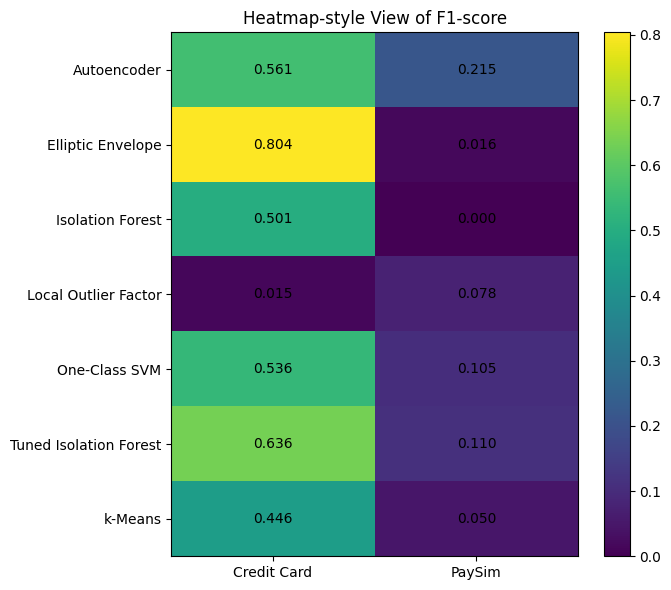

In [31]:
heatmap_f1 = advanced_comparison.pivot(index="Model", columns="Dataset", values="F1-score")
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(heatmap_f1.values, aspect="auto")

ax.set_xticks(np.arange(len(heatmap_f1.columns)))
ax.set_yticks(np.arange(len(heatmap_f1.index)))
ax.set_xticklabels(heatmap_f1.columns)
ax.set_yticklabels(heatmap_f1.index)
ax.set_title("Heatmap-style View of F1-score")

for i in range(heatmap_f1.shape[0]):
    for j in range(heatmap_f1.shape[1]):
        ax.text(j, i, f"{heatmap_f1.iloc[i, j]:.3f}", ha="center", va="center")

fig.colorbar(im)
plt.tight_layout()
plt.show()

## 15. Chart 7 — Model ranking plot

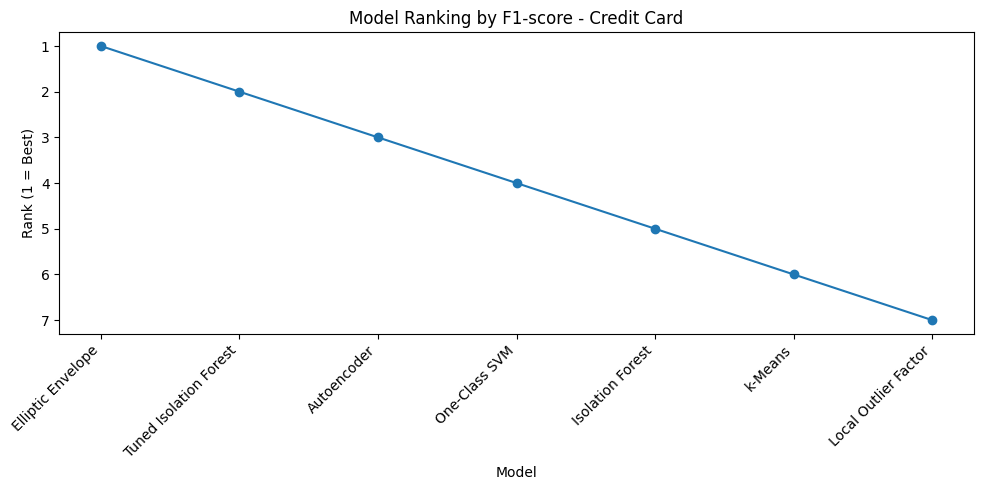

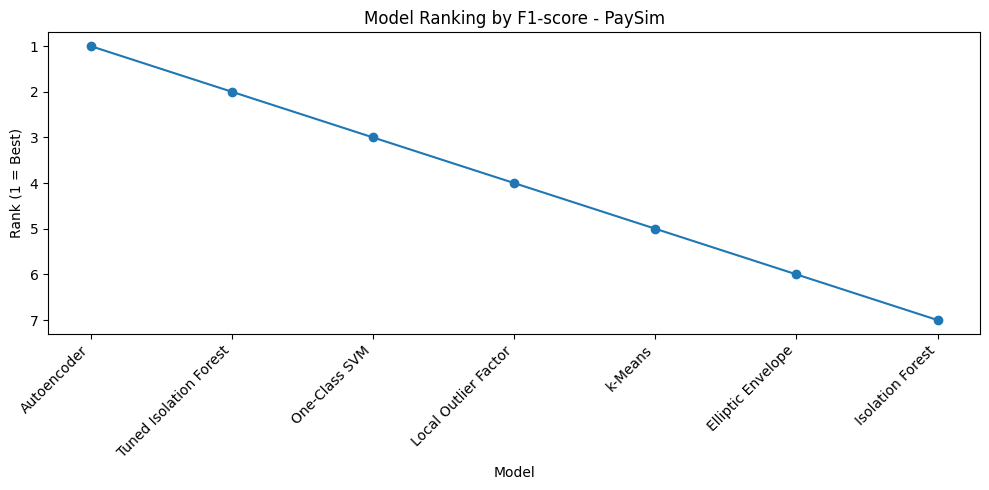

In [32]:
for dataset_name in rank_table["Dataset"].unique():
    subset = rank_table[rank_table["Dataset"] == dataset_name].sort_values("Rank")

    plt.figure(figsize=(10, 5))
    plt.plot(subset["Model"], subset["Rank"], marker="o")
    plt.gca().invert_yaxis()
    plt.title(f"Model Ranking by F1-score - {dataset_name}")
    plt.xlabel("Model")
    plt.ylabel("Rank (1 = Best)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 16. Automatic interpretation block

In [33]:
summary_rows = []

for dataset_name in advanced_comparison["Dataset"].unique():
    subset = advanced_comparison[advanced_comparison["Dataset"] == dataset_name].sort_values("F1-score", ascending=False)
    best = subset.iloc[0]
    worst = subset.iloc[-1]

    summary_rows.append({
        "Dataset": dataset_name,
        "Best Model": best["Model"],
        "Best F1-score": round(best["F1-score"], 4),
        "Best ROC-AUC": round(best["ROC-AUC"], 4),
        "Lowest Model": worst["Model"],
        "Lowest F1-score": round(worst["F1-score"], 4)
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Dataset,Best Model,Best F1-score,Best ROC-AUC,Lowest Model,Lowest F1-score
0,Credit Card,Elliptic Envelope,0.8041,0.9550,Local Outlier Factor,0.0154
1,PaySim,Autoencoder,0.2146,0.8302,Isolation Forest,0.0000


## 17. Optional download cell for Colab

In [34]:
# Uncomment in Google Colab if you want to download the files manually:
# from google.colab import files
# files.download("advanced_model_comparison.xlsx")
# files.download("combined_model_comparison_advanced.csv")